In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pyreadr
import os
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import pyreadr
from pathlib import Path
from functools import partial
import logging


In [3]:
path='D:/博士/pic(PDF&TIFF)/QTL/脚本+数据'

In [4]:
dftis = pd.read_csv(f"{path}/tissue40.list", sep="\t")
tislist = dftis['Tissue'].tolist()
tisorder = pd.read_csv(f"{path}/tissue.order", sep="\t")
palette = dict(zip(tisorder['Tissue (QTL)'], tisorder['Color']))

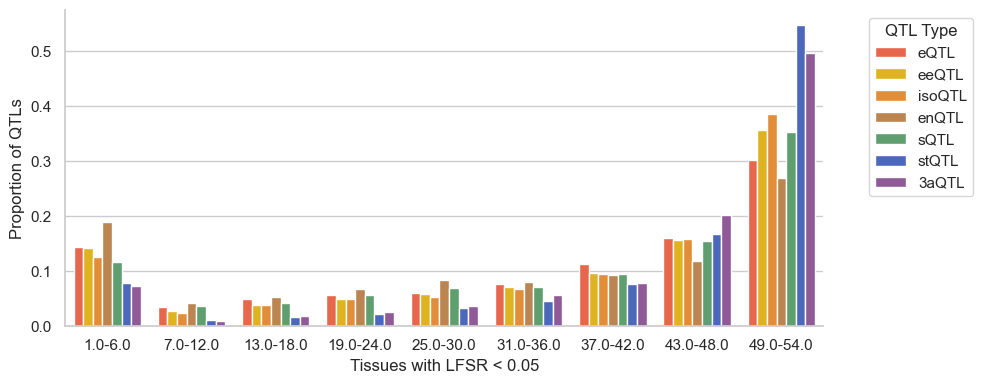

共加载了 396961 个QTL对
每种QTL类型的数量:
Type
eQTL      124307
eeQTL      67158
stQTL      64740
isoQTL     64448
sQTL       46581
3aQTL      15122
enQTL      14605
Name: count, dtype: int64


In [2]:
QTL_TYPES = ['eQTL', 'sQTL', 'eeQTL', 'isoQTL', 'stQTL', '3aQTL', 'enQTL']
QTL_ORDER = ['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL']
COLOR_DICT = {
    'eQTL': '#FF5733', 'eeQTL': '#FFC300', 'isoQTL': '#FF8D1A',
    'enQTL': '#CD853F', 'sQTL': '#55A868', 'stQTL': '#3A5FCD', '3aQTL': '#984EA3'
}

def analyze_qtl_distribution(base_path, output_path=None, lfsr_threshold=0.05, group_size=6):
    """主处理函数：加载QTL数据并生成分布图"""
    # 加载并处理数据
    dfs = []
    for idx, qtl in enumerate(QTL_TYPES, start=1):
        rds_path = Path(base_path) / f"{idx:02d}.top_pair_{qtl}" / "lfsr_m.s.RDS"
        if not os.path.exists(rds_path):
            continue
            
        # 加载RDS文件并提取显著QTL
        try:
            lfsr = pyreadr.read_r(str(rds_path))[None]
            significant = (lfsr < lfsr_threshold).sum(axis=1)
            
            # 只保留有显著性的QTL对
            if len(significant[significant > 0]) > 0:
                qtl_df = significant[significant > 0].reset_index()
                qtl_df.columns = ['pairs', 'Tissues_with_LFSR_lt_0.05']
                qtl_df[['snp', 'genes']] = qtl_df['pairs'].str.split(',', expand=True)
                qtl_df['Type'] = qtl
                dfs.append(qtl_df)
        except Exception:
            continue

    if not dfs:
        print("没有找到有效的QTL数据")
        return
        
    # 合并所有QTL数据
    df_combined = pd.concat(dfs, ignore_index=True)
    
    # 按组织数量分组
    df_combined['Tissues_with_LFSR_lt_0.05_grouped'] = df_combined['Tissues_with_LFSR_lt_0.05'].apply(
        lambda x: f"{((np.ceil(x/group_size)-1)*group_size)+1}-{np.ceil(x/group_size)*group_size}"
    )
    
    # 计算各组比例
    counts = df_combined.groupby(['Type', 'Tissues_with_LFSR_lt_0.05_grouped']).size()
    totals = df_combined.groupby('Type').size()
    proportion_df = (counts.reset_index(name='count')
                    .merge(totals.reset_index(name='total'), on='Type')
                    .assign(proportion=lambda x: x['count'] / x['total']))
    
    # 数据排序
    group_order = (df_combined
                  .drop_duplicates('Tissues_with_LFSR_lt_0.05_grouped')
                  .sort_values('Tissues_with_LFSR_lt_0.05')
                  ['Tissues_with_LFSR_lt_0.05_grouped']
                  .tolist())
    
    proportion_df['Type'] = pd.Categorical(proportion_df['Type'], 
                                          categories=QTL_ORDER, ordered=True)
    
    # 绘图
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 4))
    
    ax = sns.barplot(
        data=proportion_df,
        x="Tissues_with_LFSR_lt_0.05_grouped",
        y="proportion",
        hue="Type",
        order=group_order,
        hue_order=QTL_ORDER, 
        palette=COLOR_DICT    
    )
    
    # 设置标签和标题
    ax.set_ylabel('Proportion of QTLs', fontsize=12)
    ax.set_xlabel('Tissues with LFSR < 0.05', fontsize=12)
    
    # 图例
    ax.legend(title="QTL Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 美化和保存
    sns.despine()
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=300)
    
    plt.show()
    print(f"共加载了 {len(df_combined)} 个QTL对")
    print(f"每种QTL类型的数量:\n{df_combined['Type'].value_counts()}")
    
    return ax

# 执行分析
if __name__ == "__main__":
    analyze_qtl_distribution(
        base_path="D:/博士/pic(PDF&TIFF)/QTL/脚本+数据",
        output_path="D:/博士/pic(PDF&TIFF)/QTL/脚本+数据/QTL_Distribution.pdf"
    )

In [ ]:
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"
prefix = ['e', 'ee', 'iso', 'en', 's', 'st', '3a']
qtl_names = ['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', "3'aQTL"]

# 读取所有类型QTL数据并合并
all_data = []
for i, p in enumerate(prefix):
    df = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t', 
                     usecols=['Tissue', 'Sample size', '1', '2', '3', 'geq4', 'Color'])
    df.rename(columns={'geq4':'≥ 4'}, inplace=True)
    df['QTL_type'] = qtl_names[i]
    df['Tissue'] = df['Tissue'].str.replace('_', ' ')
    all_data.append(df)

combined_df = pd.concat(all_data)

# 对组织按样本量排序（取一种QTL类型的排序即可）
tissue_order = all_data[0].sort_values('Sample size', ascending=False)['Tissue'].tolist()


fig = plt.figure(figsize=(20, 10))
gs = GridSpec(len(qtl_names), len(tissue_order), figure=fig, wspace=0.1, hspace=0.1)
rank_columns = ['1', '2', '3', '≥ 4']
colors = sns.color_palette("Blues", 4) 

# 添加饼图
for i, qtl in enumerate(qtl_names):
    for j, tissue in enumerate(tissue_order):
        subset = combined_df[(combined_df['QTL_type'] == qtl) & (combined_df['Tissue'] == tissue)]

        if not subset.empty:
            values = subset[rank_columns].values[0]
            total = values.sum()
            if total > 0:
                ax = fig.add_subplot(gs[i, j])
                wedges, _ = ax.pie(values, colors=colors)
                ax.axis('equal')
                ax.set_xticks([])
                ax.set_yticks([])


for i, qtl in enumerate(qtl_names):
    ax = fig.add_subplot(gs[i, -1])
    ax.axis('off')
    ax.text(1.1, 0.5, qtl, va='center', ha='left',fontweight='bold')

for j, tissue in enumerate(tissue_order):
    ax = fig.add_subplot(gs[-1, j])
    ax.axis('off')
    ax.text(0.5, -0.5, tissue, va='top', ha='right', rotation=45)

# 添加图例 - 确保顺序与数据一致
legend_ax = fig.add_axes([0.92, 0.6, 0.05, 0.3])
legend_ax.axis('off')
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(4)]
labels = ['1', '2', '3', '≥ 4']  # 顺序与数据和颜色对应
legend_ax.legend(handles, labels, loc='center', title='QTLs/gene')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
#plt.savefig('QTL_pie_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()
